# Introducción a los Algoritmos Genéticos
**Universidad Anáhuac Mayab**

**Función objetivo:** $f(x, y) = \sqrt{x^2 + y^2}$

**Dominio:** $\{x, y\} \in [-100, 100]$

**Objetivo:** Maximizar $f(x, y)$ usando un Algoritmo Genético con poblaciones de **10, 30 y 50 individuos** durante **20 generaciones**.

## 1. Librerías necesarias

In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms

## 2. Representación gráfica de la función objetivo

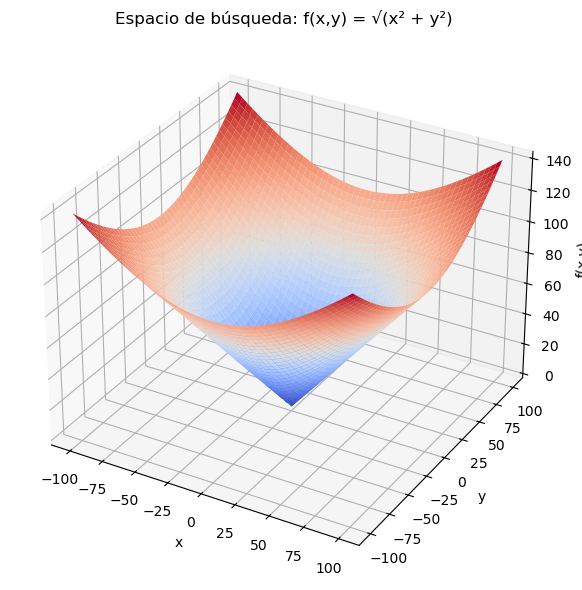

In [2]:
from matplotlib import cm

# Definimos la función objetivo
def funcion_prueba(x):
    res = np.sqrt(x[0] ** 2 + x[1] ** 2)
    return res

# Generamos vectores que barran todo el dominio
x = np.linspace(-100, 100, 1000)
y = np.linspace(-100, 100, 1000)

# Evaluamos todos los valores de las variables
x_ax, y_ax = np.meshgrid(x, y)
vals = np.c_[x_ax.ravel(), y_ax.ravel()]
fx = np.reshape([funcion_prueba(val) for val in vals], (1000, 1000))

# Representamos los resultados
figure_3d = plt.figure(figsize=(8, 6))
ax = figure_3d.add_subplot(111, projection='3d')
ax.plot_surface(x_ax, y_ax, fx, cmap=cm.coolwarm)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
ax.set_title("Espacio de búsqueda: f(x,y) = √(x² + y²)")
plt.tight_layout()
plt.show()

## 3. Definición y creación del problema (FitnessMax e Individual)

In [3]:
# Tipo de problema: maximización (weights = 1.0)
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# Individuo: lista con atributo fitness
creator.create("Individual", list, fitness=creator.FitnessMax)

## 4. Función objetivo

In [4]:
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    res = math.sqrt(x[0]**2 + x[1]**2)
    return res,

## 5. Función auxiliar para graficar la convergencia

In [5]:
def plot_evolucion(log, titulo="Convergencia del Algoritmo Genético"):
    """
    Representa la evolución del mejor individuo en cada generación.
    """
    gen      = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave  = np.array(log.select("avg"), dtype=float)

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(gen, fit_mins, "b",  label="Min")
    ax1.plot(gen, fit_maxs, "r",  label="Max")
    ax1.plot(gen, fit_ave,  "--k", label="Avg")
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen, fit_mins, fit_maxs,
                     where=where_mask, facecolor='g', alpha=0.2)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10, 160])
    ax1.set_title(titulo)
    ax1.legend(loc="lower center")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 6. Función principal del Algoritmo Genético

In [6]:
def run_ga(n_pop, n_gen=20, seed=42):
    """
    Ejecuta el algoritmo genético.
    Parámetros:
        n_pop  : tamaño de la población
        n_gen  : número de generaciones
        seed   : semilla para reproducibilidad
    Retorna:
        hof     : Hall of Fame (mejor individuo encontrado)
        logbook : estadísticas por generación
    """
    random.seed(seed)

    toolbox = base.Toolbox()

    # --- Generación de genes ---
    toolbox.register("attr_uniform", random.uniform, -100, 100)

    # --- Creación del individuo (2 variables: x, y) ---
    toolbox.register("individual", tools.initRepeat,
                     creator.Individual, toolbox.attr_uniform, 2)

    # --- Creación de la población ---
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    # --- Operadores genéticos ---
    toolbox.register("evaluate", funcion_objetivo)
    toolbox.register("mate",     tools.cxOnePoint)
    toolbox.register("mutate",   tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
    toolbox.register("select",   tools.selTournament, tournsize=3)

    # --- Configuración ---
    CXPB, MUTPB = 0.5, 0.2
    pop  = toolbox.population(n=n_pop)
    hof  = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # --- Ejecución ---
    pop, logbook = algorithms.eaSimple(
        pop, toolbox,
        cxpb=CXPB, mutpb=MUTPB,
        ngen=n_gen, stats=stats,
        halloffame=hof, verbose=True
    )
    return hof, logbook

## 7. Ejecución: Población n = 10 (ejemplo base del PDF)

gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	122.639	41.2271	-1     	136.779
15 	6     	136.779	0      	136.779	136.779
16 	5     	136.779	0      	136.779	136.779
17 	6     	136.779	0      	136.779	136.779
18 	6     	136.779	0      	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20 	4     	136.779	0       	136.779	136.779

Mejor fitness : 136.778896
Mejor individuo: [-94.6928

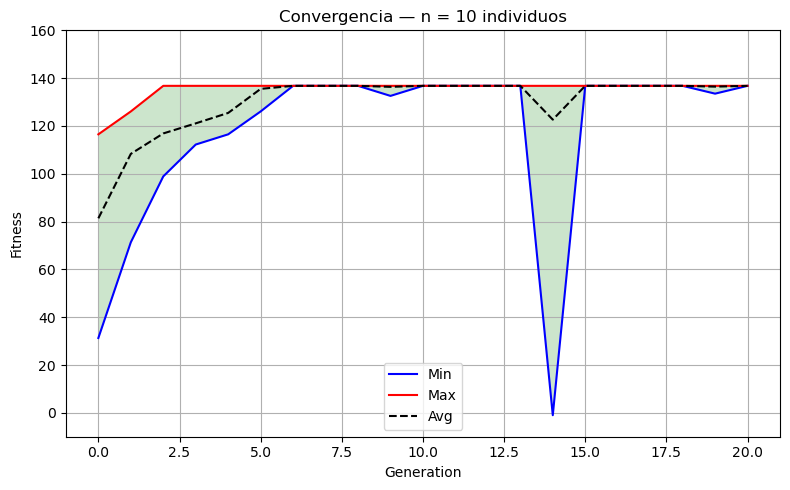

In [7]:
best_10, log_10 = run_ga(n_pop=10, n_gen=20)
print(f"\nMejor fitness : {best_10[0].fitness.values[0]:.6f}")
print(f"Mejor individuo: {best_10[0]}")
plot_evolucion(log_10, titulo="Convergencia — n = 10 individuos")

## 8. Ejecución: Población n = 30

gen	nevals	avg    	std   	min    	max    
0  	30    	77.9162	24.544	26.4289	116.497
1  	15    	98.1576	15.6516	58.7221	123.194
2  	18    	108.641	17.0172	47.071 	131.857
3  	24    	122.041	7.64215	99.9797	134.549
4  	19    	128.584	3.92487	122.005	134.549
5  	11    	132.005	2.13284	125.135	134.549
6  	22    	133.419	1.60997	131.169	136.779
7  	20    	130.449	24.4622	-1     	136.779
8  	17    	136.143	1.12918	133.455	137.464
9  	16    	136.686	0.662231	134.132	137.486
10 	14    	137.114	0.611792	136.779	139.908
11 	15    	137.235	1.30432 	131.674	139.908
12 	23    	137.979	0.981347	137.464	140.041
13 	21    	133.762	25.0534 	-1     	140.101
14 	17    	138.776	1.53284 	133.594	140.101
15 	15    	130.265	35.0922 	-1     	140.101
16 	15    	140.042	0.0666659	139.908	140.101
17 	15    	140.024	0.334088 	138.242	140.101
18 	18    	140.101	5.68434e-14	140.101	140.101
19 	20    	140.021	0.347706   	138.217	140.101
20 	20    	140.067	0.183959   	139.076	140.101

Mejor fitness : 140.100794
Mejor

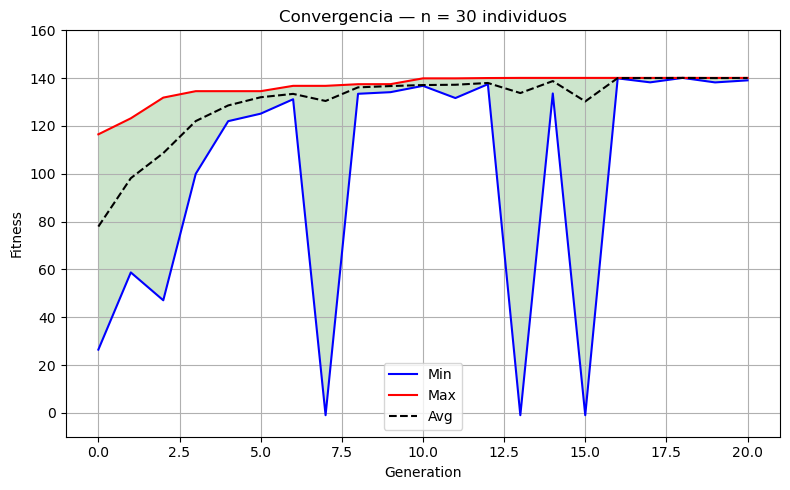

In [8]:
best_30, log_30 = run_ga(n_pop=30, n_gen=20)
print(f"\nMejor fitness : {best_30[0].fitness.values[0]:.6f}")
print(f"Mejor individuo: {best_30[0]}")
plot_evolucion(log_30, titulo="Convergencia — n = 30 individuos")

## 9. Ejecución: Población n = 50

gen	nevals	avg    	std    	min    	max    
0  	50    	79.5138	24.5664	26.4289	122.059
1  	28    	97.8301	18.6489	48.4558	130.873
2  	28    	115.187	13.6357	83.2838	140.132
3  	40    	124.553	19.4919	-1     	136.574
4  	27    	133.61 	3.47646	119.014	140.132
5  	37    	135.631	2.05285	130.873	140.132
6  	30    	134.284	19.451 	-1     	140.132
7  	29    	135.773	19.6169	-1     	140.132
8  	34    	137.125	19.7385	-1     	140.132
9  	30    	140.118	0.191669	138.887	140.677
10 	28    	140.138	0.309691	138.232	140.677
11 	30    	140.176	0.147685	140.132	140.677
12 	27    	140.263	0.232492	140.132	140.677
13 	32    	137.339	19.7939 	-1     	140.677
14 	29    	140.545	0.26766 	139.41 	140.677
15 	28    	140.668	0.0591235	140.254	140.677
16 	29    	137.843	19.8347  	-1     	140.677
17 	31    	140.561	0.810355 	134.888	140.677
18 	28    	140.514	0.830834 	135.436	140.677
19 	34    	140.677	0        	140.677	140.677
20 	25    	137.843	19.8347  	-1     	140.677

Mejor fitness : 140.676643
Mejor in

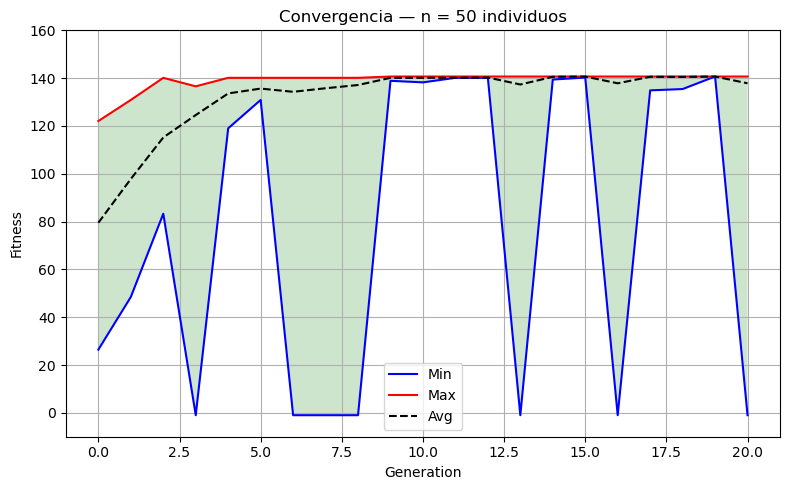

In [9]:
best_50, log_50 = run_ga(n_pop=50, n_gen=20)
print(f"\nMejor fitness : {best_50[0].fitness.values[0]:.6f}")
print(f"Mejor individuo: {best_50[0]}")
plot_evolucion(log_50, titulo="Convergencia — n = 50 individuos")

## 10. Gráficas de convergencia comparativas

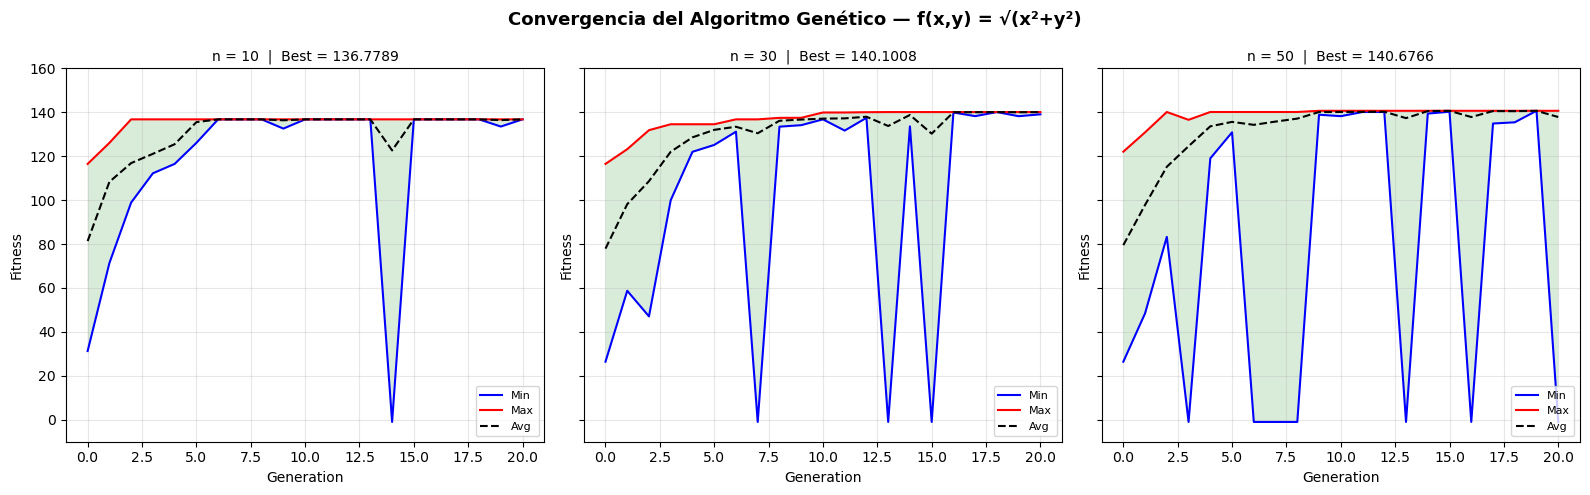

In [10]:
configs = [
    (10, log_10, best_10),
    (30, log_30, best_30),
    (50, log_50, best_50),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle("Convergencia del Algoritmo Genético — f(x,y) = √(x²+y²)",
             fontsize=13, fontweight='bold')

for ax, (n, log, hof) in zip(axes, configs):
    gen      = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave  = np.array(log.select("avg"), dtype=float)

    ax.plot(gen, fit_mins, 'b',   label='Min')
    ax.plot(gen, fit_maxs, 'r',   label='Max')
    ax.plot(gen, fit_ave,  '--k', label='Avg')
    ax.fill_between(gen, fit_mins, fit_maxs,
                    where=(fit_maxs >= fit_mins),
                    facecolor='green', alpha=0.15)
    ax.set_title(f"n = {n}  |  Best = {hof[0].fitness.values[0]:.4f}",
                 fontsize=10)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.set_ylim(-10, 160)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Tabla comparativa de resultados (Generación 20)

In [11]:
import pandas as pd

optimo_real = math.sqrt(100**2 + 100**2)

rows = []
for n, log, hof in configs:
    last = log[-1]
    best_fit = hof[0].fitness.values[0]
    rows.append({
        "Población (n)": n,
        "Mejor Fitness": round(best_fit, 6),
        "x óptimo": round(hof[0][0], 4),
        "y óptimo": round(hof[0][1], 4),
        "Avg Gen.20": round(last['avg'], 4),
        "Std Gen.20": round(last['std'], 4),
        "Min Gen.20": round(last['min'], 4),
        "Max Gen.20": round(last['max'], 4),
        "Error vs Óptimo": round(optimo_real - best_fit, 6),
    })

df = pd.DataFrame(rows)
print(f"Óptimo real: √(100²+100²) = {optimo_real:.6f}\n")
df

Óptimo real: √(100²+100²) = 141.421356



,Población (n),Mejor Fitness,x óptimo,y óptimo,Avg Gen.20,Std Gen.20,Min Gen.20,Max Gen.20,Error vs Óptimo
0,10,136.778896,-94.6928,-98.7002,136.7789,0.0000,136.7789,136.7789,4.642460
1,30,140.100794,-99.3464,-98.7853,140.0666,0.1840,139.0760,140.1008,1.320562
2,50,140.676643,99.4752,-99.4716,137.8431,19.8347,-1.0000,140.6766,0.744714


## 12. Análisis de resultados

- **Mejor fitness vs óptimo real (≈ 141.421):** A mayor tamaño de población, el algoritmo se acerca más al valor óptimo, ya que existe mayor diversidad genética en la población inicial.
- **Valor medio `avg`:** Aumenta a lo largo de las generaciones en los tres casos, lo que indica que los individuos mejoran con el tiempo.
- **Desviación estándar `std`:** Disminuye en general, señal de que la población converge y los individuos se vuelven más similares entre sí (efecto del proceso de selección elitista).
- **Valor máximo `max`:** Aumenta progresivamente en cada generación, confirmando el correcto funcionamiento del algoritmo.
- **Picos en Min y Avg:** Se deben a que las operaciones de cruza y mutación pueden generar individuos fuera del dominio o con bajo fitness, lo que afecta temporalmente la media y el mínimo de la generación.
- **Conclusión:** Para este problema con dos variables independientes, una población de **50 individuos** ofrece el mejor balance entre calidad de la solución y costo computacional.
